# Sistema Fuzzy para Risco de Evasão Acadêmica

## Apoio interpretável à intervenção durante a trajetória acadêmica

Este estudo investiga se quatro sistemas Mamdani, com regras aprendidas automaticamente, conseguem organizar sinais acadêmicos, sociais e demográficos em um risco contínuo de evasão entre 0 e 100. O sistema não é uma triagem de admissão: ele pretende apoiar uma ação humana antes que a evasão aconteça.

## 1. Preparação e protocolo

A classe `Enrolled` é removida. Os estudantes restantes são separados de forma estratificada em 70% treino, 15% validação e 15% teste. O treino aprende as regras, a validação seleciona o limiar por F2 e o teste é reservado para a avaliação final.

> **Depois de editar os arquivos em src/blocks:** execute novamente a célula de configuração e a célula que cria o objeto experiment — ou use **Run All**. Executar somente as células dos gráficos reutiliza o modelo antigo que já está na memória.

In [ ]:
from __future__ import annotations

import os
import sys
from pathlib import Path
from typing import Sequence

sys.path.insert(0, os.path.abspath('.'))

%load_ext autoreload
%autoreload 1
%aimport src.blocks.academic, src.blocks.social, src.blocks.demographic, src.blocks.final

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

from src import data, evaluate
from src.experiment import ExperimentResult, export_experiment, run_experiment

%matplotlib inline
pd.set_option('display.max_colwidth', 140)
OUTPUT_DIR = Path('outputs')

def show_images(paths: Sequence[Path], *, width: int = 760) -> None:
    for path in paths:
        display(Image(filename=str(path), width=width))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
raw = data.load_raw(use_cache=True)
students = data.build_features(raw)
experiment: ExperimentResult = run_experiment(students, random_state=42, folds=5, bootstrap_iterations=1000)
export_experiment(experiment, OUTPUT_DIR)

split_summary = pd.DataFrame({
    'particao': ['Treino', 'Validacao', 'Teste'],
    'n': [len(experiment.split.train), len(experiment.split.validation), len(experiment.split.test)],
    'taxa_dropout': [
        experiment.split.train['y_true'].mean(),
        experiment.split.validation['y_true'].mean(),
        experiment.split.test['y_true'].mean(),
    ],
})
split_summary

,particao,n,taxa_dropout
0,Treino,2541,0.391578
1,Validacao,544,0.391544
2,Teste,545,0.390826


In [ ]:
# Confirma as funções de pertinência realmente usadas pelo modelo recém-treinado.
configuracao_ativa: list[dict[str, object]] = []
for nome_sistema, modelo in experiment.pipeline.models.items():
    for variavel in modelo.variables:
        for nome_termo, funcao in variavel.terms.items():
            configuracao_ativa.append({
                'sistema': nome_sistema,
                'variavel': variavel.name,
                'termo': nome_termo,
                'tipo': funcao.kind,
                'parametros': funcao.parameters,
            })

pd.DataFrame(configuracao_ativa)

,sistema,variavel,termo,tipo,parametros
0,academico,nota_academica,baixa,trapmf,"(0.0, 0.0, 8.0, 10.0)"
1,academico,nota_academica,media,trimf,"(8.0, 10.0, 15.0)"
2,academico,nota_academica,alta,trapmf,"(10.0, 15.0, 20.0, 20.0)"
3,academico,aprovadas,poucas,trapmf,"(0.0, 0.0, 1.0, 2.0)"
4,academico,aprovadas,medias,trimf,"(1.0, 2.0, 5.0)"
5,academico,aprovadas,muitas,trapmf,"(2.0, 5.0, 26.0, 26.0)"
6,academico,sem_avaliacao,poucas,trapmf,"(0.0, 0.0, 0.5, 1.0)"
7,academico,sem_avaliacao,medias,trimf,"(0.5, 1.0, 3.0)"
8,academico,sem_avaliacao,muitas,trapmf,"(1.0, 3.0, 12.0, 12.0)"
9,social,debtor,nao,binary_false,()


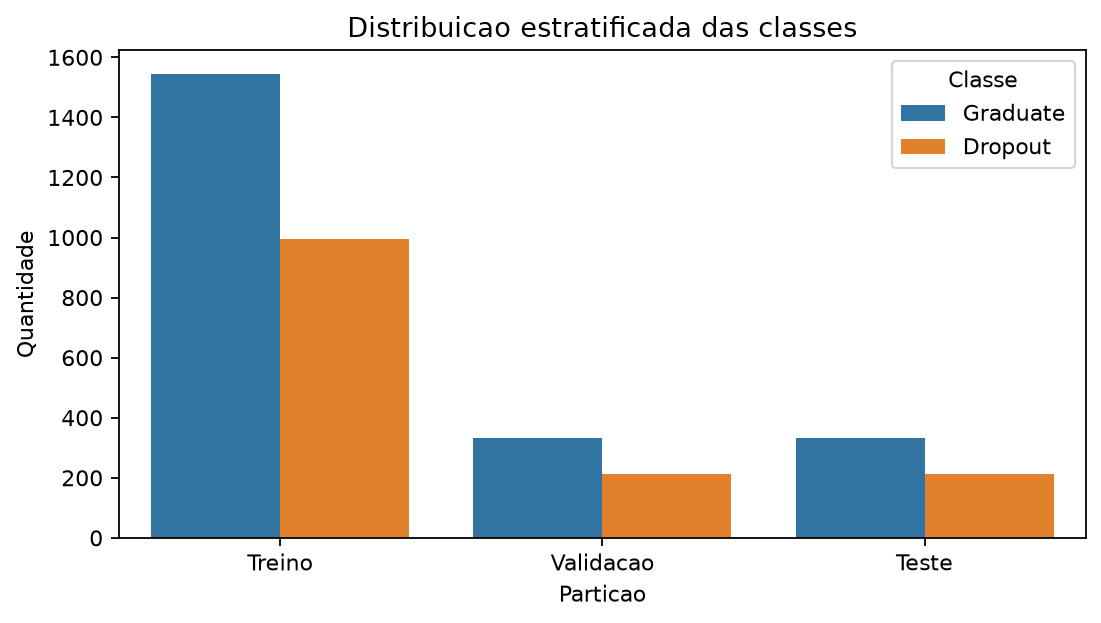

In [ ]:
show_images([OUTPUT_DIR / 'split_distribution.png'])

## 2. Arquitetura fuzzy hierárquica

Os subsistemas acadêmico, social/financeiro e demográfico produzem riscos intermediários. O sistema final aprende a combiná-los usando predições *out-of-fold*, evitando que ele seja treinado com riscos produzidos pelos mesmos exemplos usados no ajuste dos subsistemas.

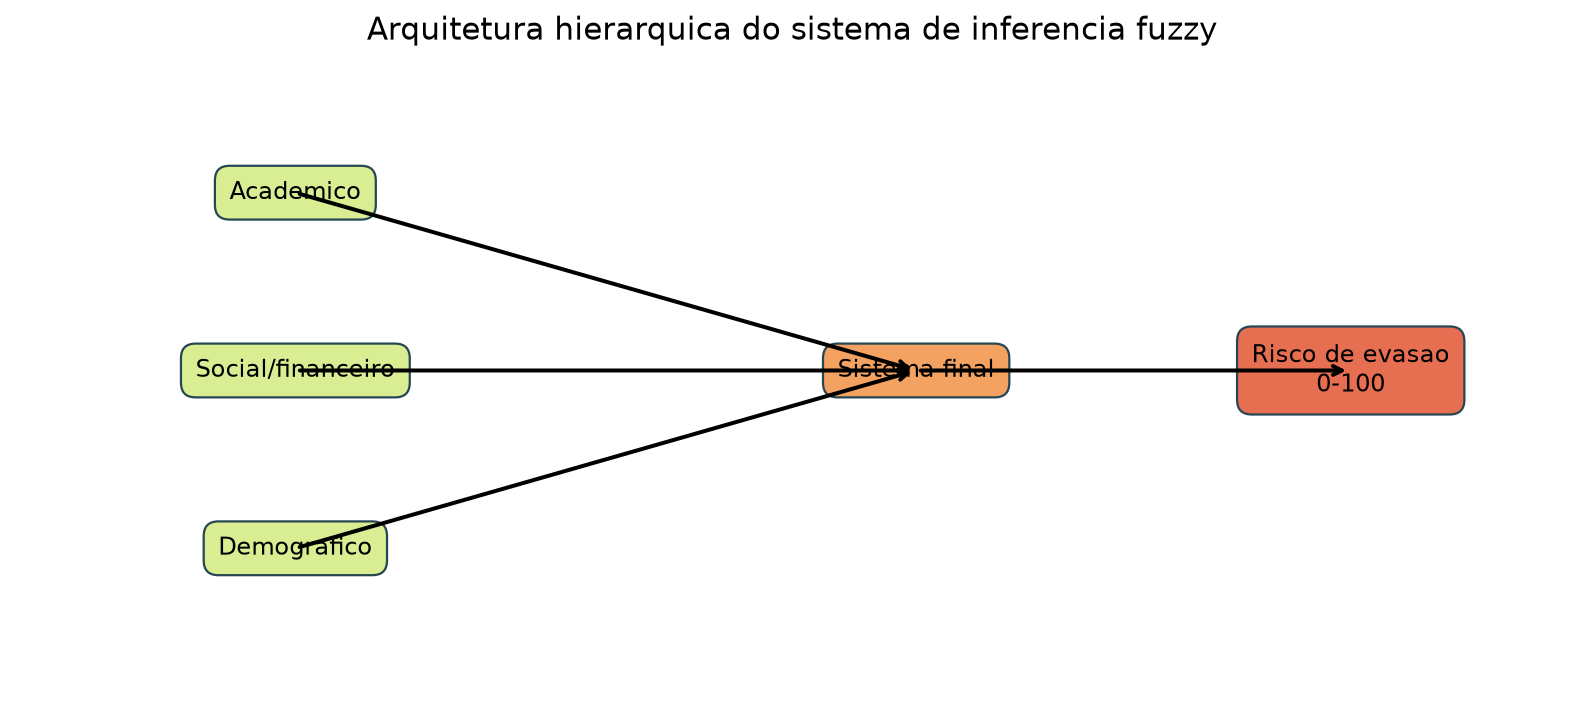

In [ ]:
show_images([OUTPUT_DIR / 'system_diagram.png'])

## 3. Pertinência, regras aprendidas e centroide

As funções de entrada preservam faixas linguísticas definidas por domínio. A base de regras é induzida no treino por uma grade fuzzy ponderada. A inferência usa mínimo, máximo e defuzzificação pelo centroide da área de saída agregada.

### 3.1 Como uma regra é aprendida — fórmulas com nomes simples

Considere uma regra candidata do sistema acadêmico:

> **SE** nota é baixa **E** aprovações são poucas **E** unidades sem avaliação são muitas **ENTÃO** risco acadêmico é alto.

Para cada aluno $i$, calculamos a **força do aluno na regra** pegando a menor pertinência entre as condições:

$$
forca_i = \min(grau\_nota_i,\ grau\_aprovacoes_i,\ grau\_sem\_avaliacao_i)
$$

Exemplo: se os três graus forem 0,30, 0,80 e 0,50, então $forca_i = 0,30$. O mínimo representa o operador **E** da lógica fuzzy.

O **suporte da regra** é a soma da força de todos os alunos:

$$
suporte\_regra = \sum_i forca_i
$$

Como a participação pode ser parcial, o suporte pode ser decimal. Regras com $suporte\_regra < 1$ são descartadas.

Depois, somamos apenas a participação associada à evasão. $evasao_i$ vale 1 para Dropout e 0 para Graduate:

$$
evasoes\_ponderadas = \sum_i (forca_i \times evasao_i)
$$

O risco da regra é suavizado pela taxa geral de evasão do treino, evitando confiar demais em regras com poucos alunos:

$$
risco\_estimado = 100 \times
\frac{evasoes\_ponderadas + 5 \times taxa\_geral\_evasao}
{suporte\_regra + 5}
$$

O número 5 é a **força da suavização**: funciona como cinco exemplos adicionais seguindo a média geral do treino.

**Exemplo numérico:** se $suporte\_regra = 20$, $evasoes\_ponderadas = 15$ e $taxa\_geral\_evasao = 0,39$:

$$
risco\_estimado = 100 \times \frac{15 + 5 \times 0{,}39}{20 + 5} = 67{,}8
$$

Por fim, verificamos se 67,8 pertence mais ao risco baixo, médio ou alto:

$$
consequente = \operatorname*{arg\,max}_{nivel \in \{baixo, medio, alto\}}
\mu_{nivel}(risco\_estimado)
$$

$$
peso\_regra = \mu_{consequente}(risco\_estimado)
$$

Assim, os campos do CSV significam: **support** = suporte, **estimated_risk** = risco suavizado, **consequent** = nível escolhido e **weight** = confiança desse nível.

### 3.2 Como as regras geram o risco de um novo aluno

Primeiro calculamos quanto cada regra dispara para o novo aluno:

$$
disparo\_regra = peso\_regra \times \min(graus\_das\_condicoes)
$$

A regra recorta a curva do seu consequente na altura do disparo:

$$
saida\_da\_regra(risco) = \min(disparo\_regra,\ \mu_{consequente}(risco))
$$

Todas as regras são reunidas pelo maior valor em cada ponto da saída:

$$
saida\_agregada(risco) = \max_{regra}(saida\_da\_regra(risco))
$$

Finalmente, o **centroide** transforma a curva agregada em um único risco entre 0 e 100:

$$
risco\_final =
\frac{\int_0^{100} risco \times saida\_agregada(risco)\,drisco}
{\int_0^{100} saida\_agregada(risco)\,drisco}
$$

Em palavras: o centroide encontra o ponto de equilíbrio da área da saída fuzzy. Se nenhuma regra disparar, usamos a taxa geral de evasão observada no treino como resultado neutro de segurança.

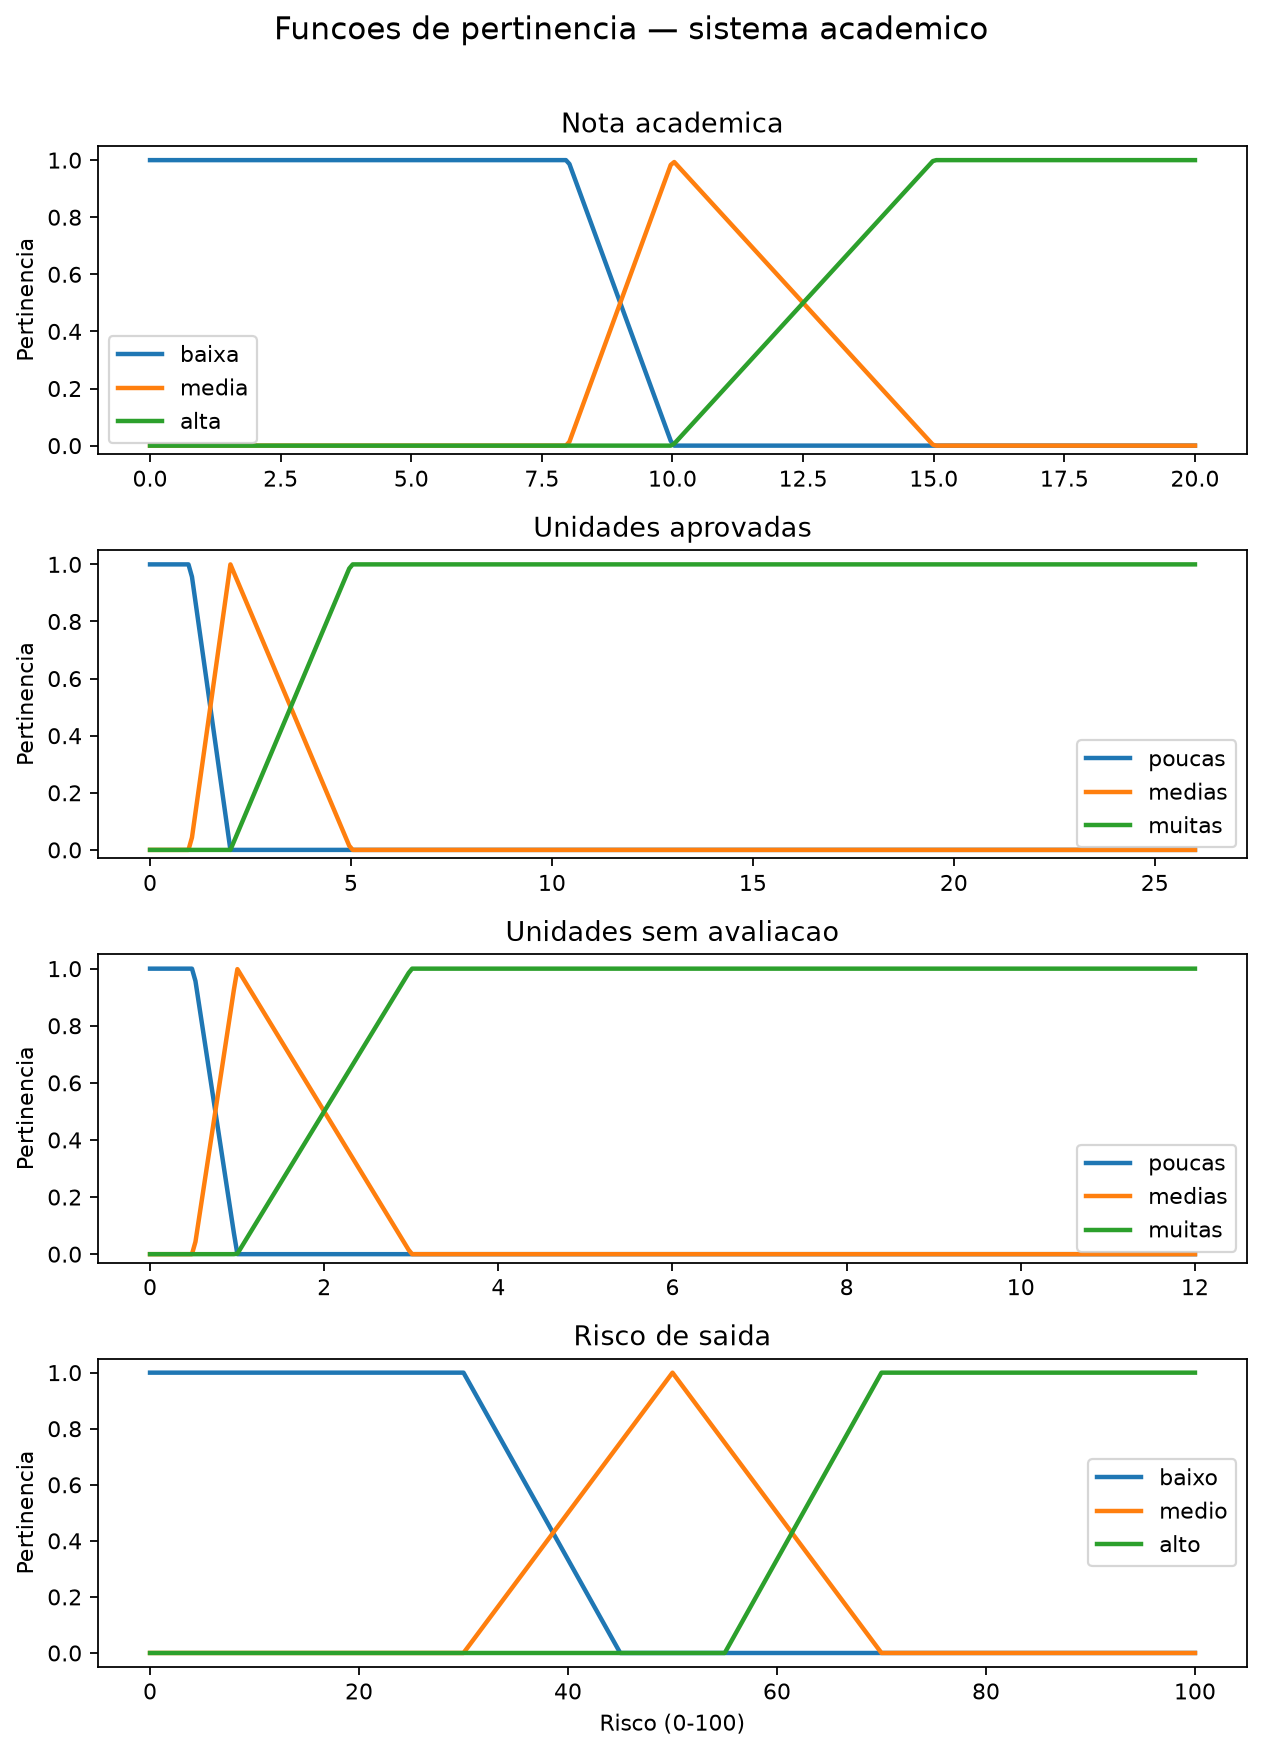

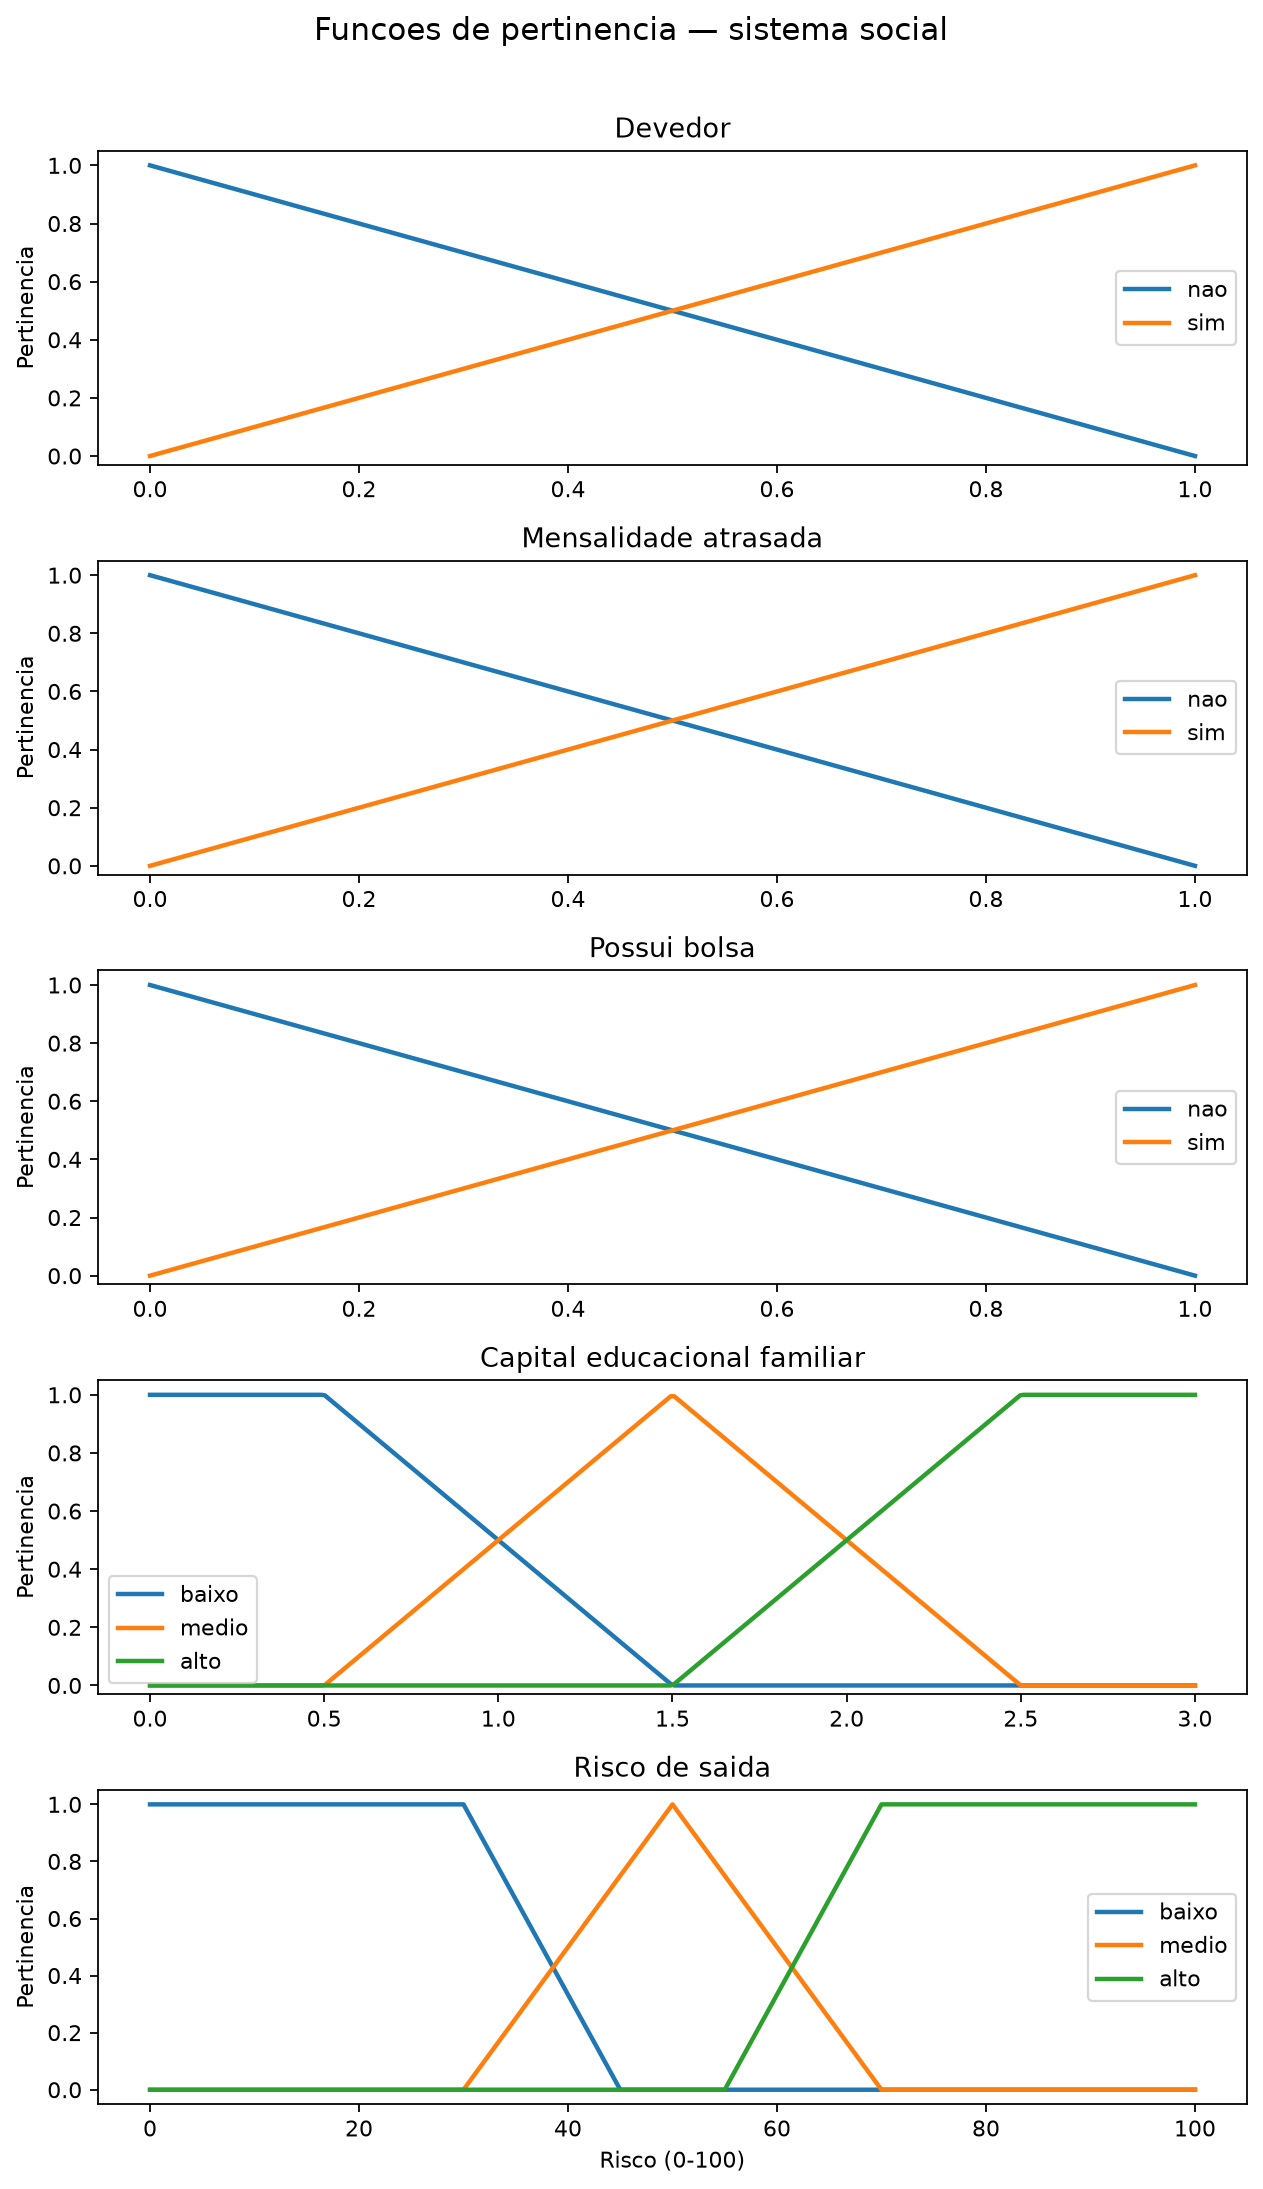

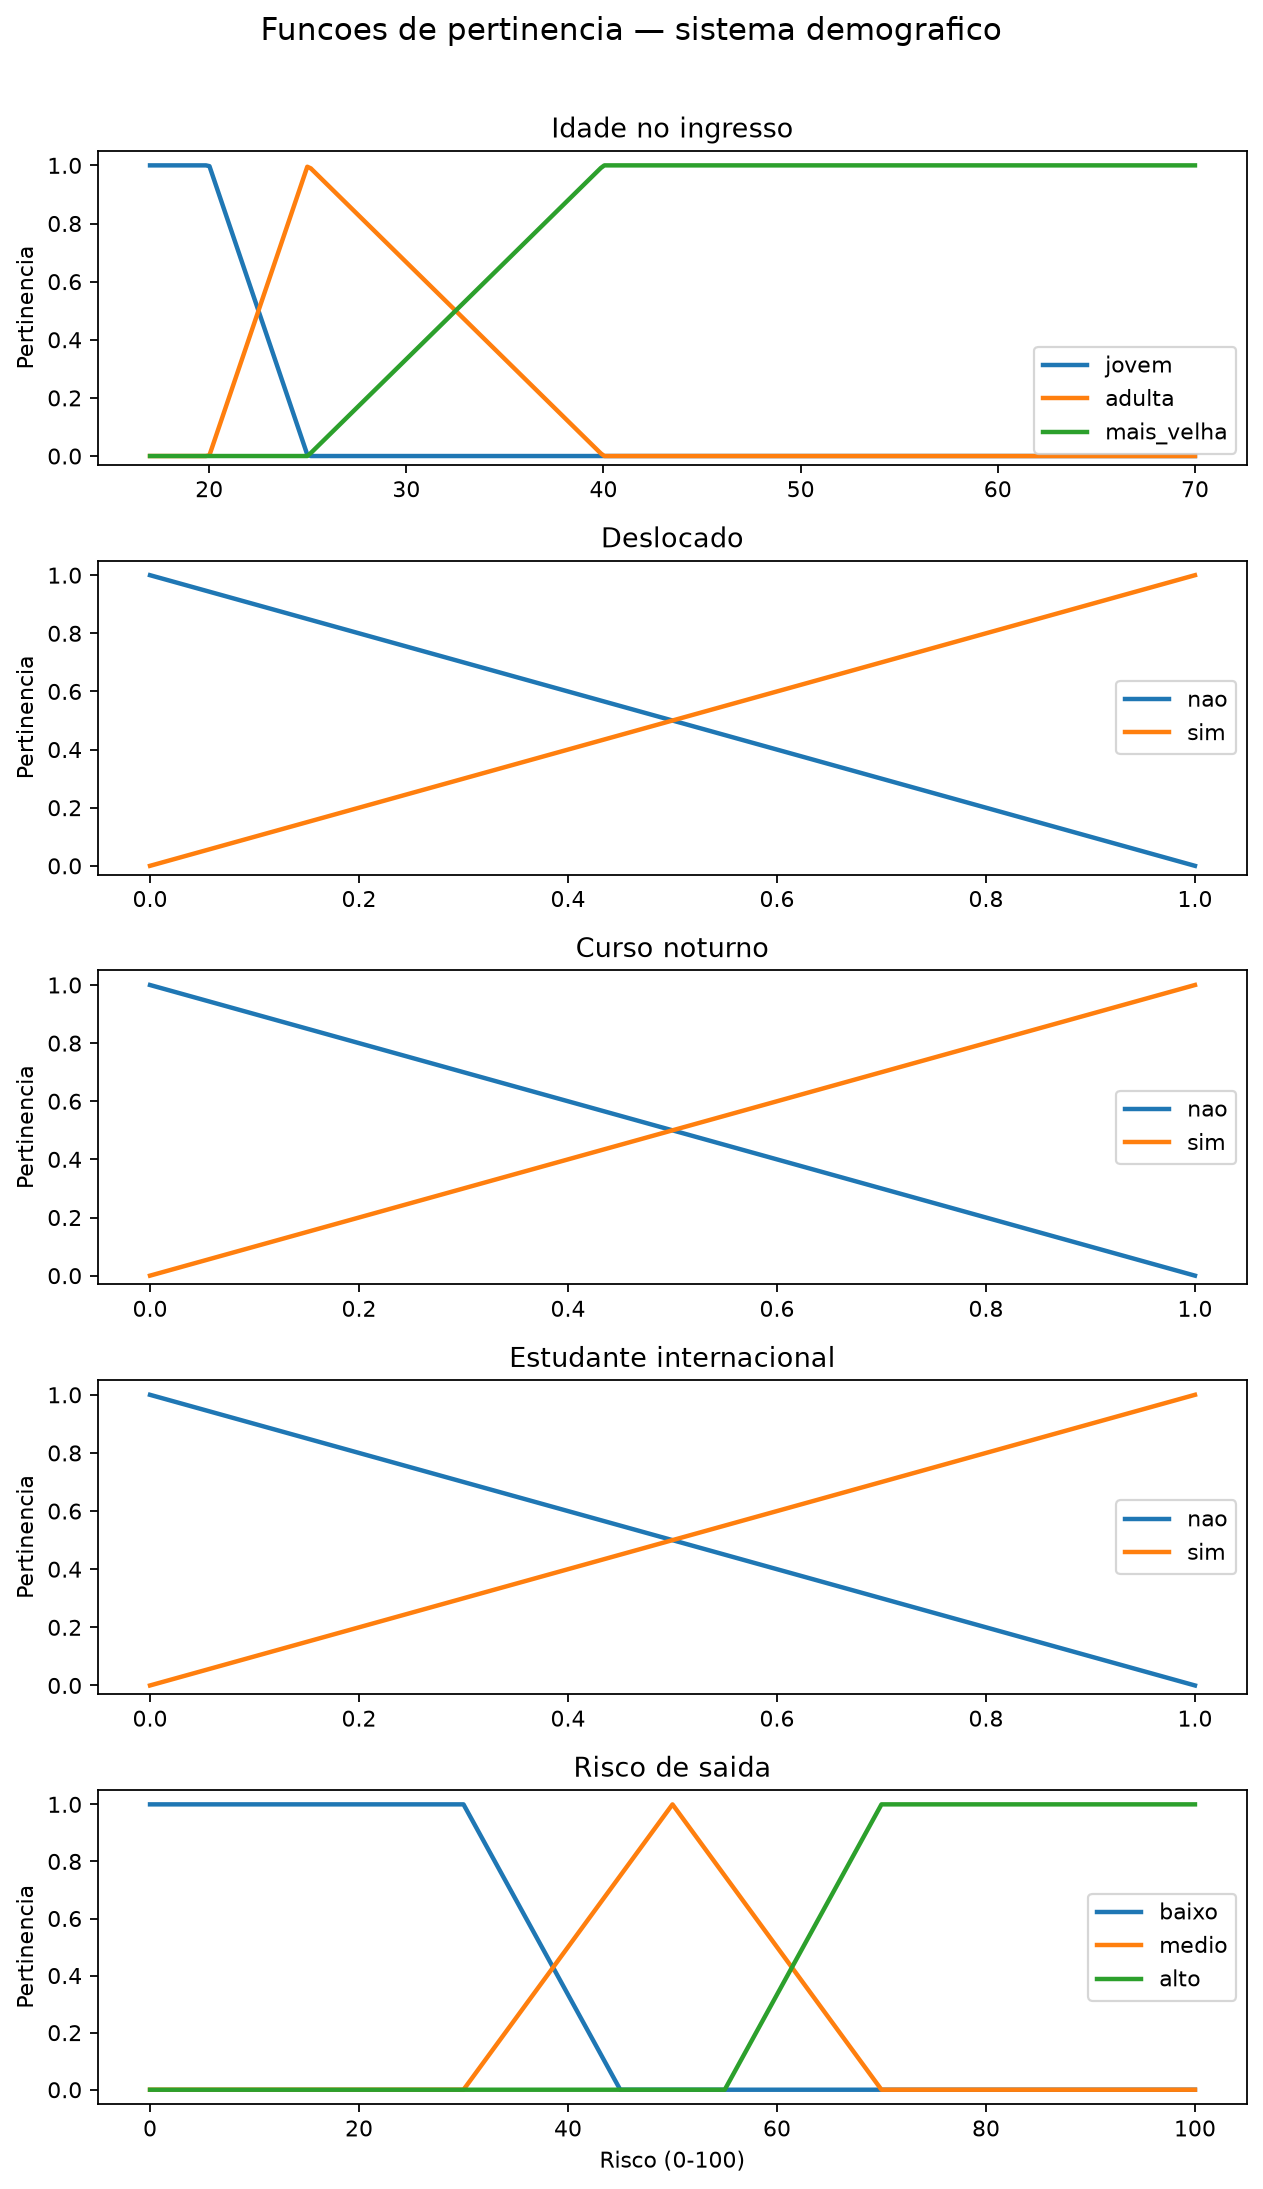

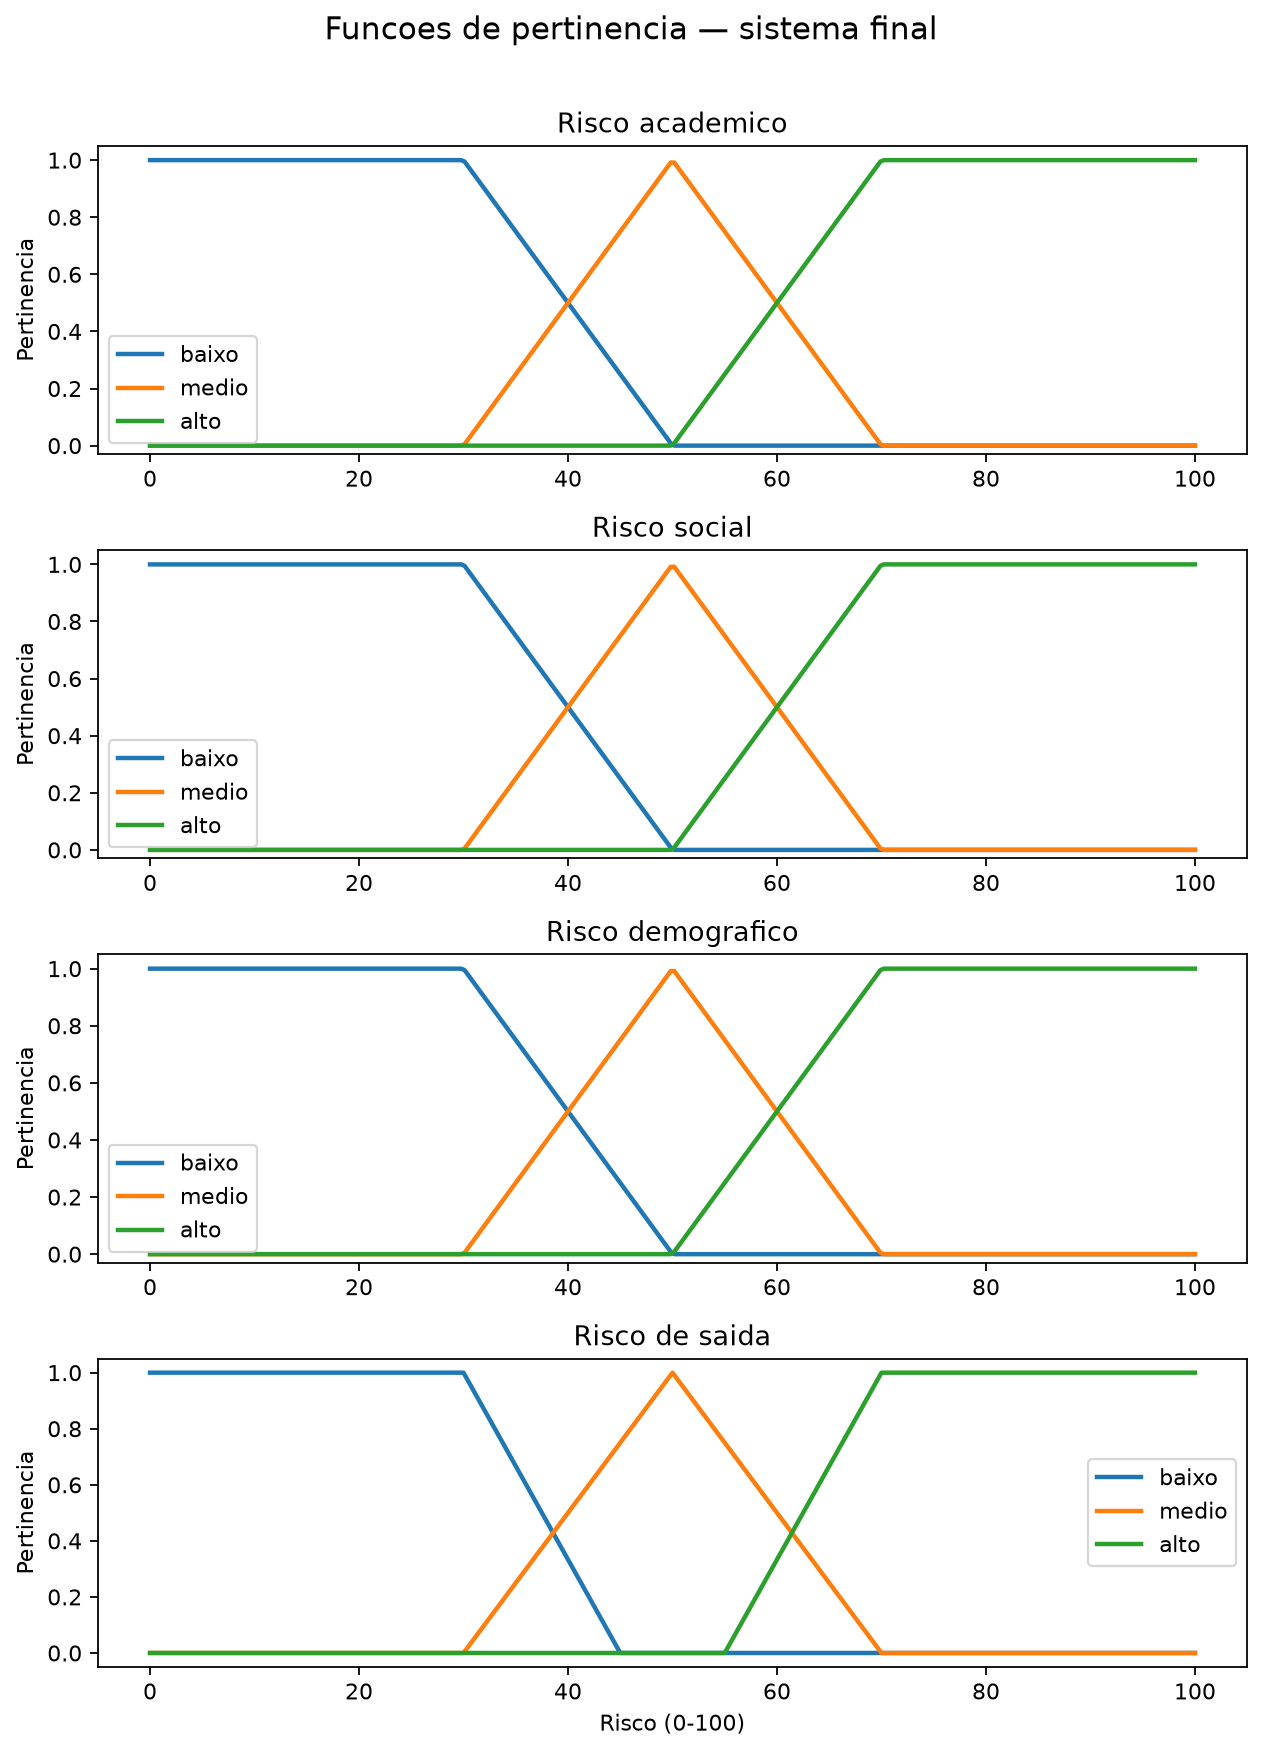

In [ ]:
show_images([
    OUTPUT_DIR / 'memberships_academico.png',
    OUTPUT_DIR / 'memberships_social.png',
    OUTPUT_DIR / 'memberships_demografico.png',
    OUTPUT_DIR / 'memberships_final.png',
])

In [ ]:
for system_name in ('academico', 'social', 'demografico', 'final'):
    rules = pd.read_csv(OUTPUT_DIR / f'rules_{system_name}.csv')
    print(f'\nSistema {system_name}: {len(rules)} regras retidas')
    display(rules.sort_values(['support', 'weight'], ascending=False).head(10))


Sistema academico: 25 regras retidas


,rule,consequent,support,estimated_risk,weight
22,SE nota_academica=alta E aprovadas=muitas E sem_avaliacao=poucas ENTAO risco=baixo,baixo,1033.006260,16.283438,1.00000
13,SE nota_academica=media E aprovadas=muitas E sem_avaliacao=poucas ENTAO risco=baixo,baixo,740.078811,23.143108,1.00000
0,SE nota_academica=baixa E aprovadas=poucas E sem_avaliacao=poucas ENTAO risco=alto,alto,473.452222,89.540835,1.00000
10,SE nota_academica=media E aprovadas=medias E sem_avaliacao=poucas ENTAO risco=alto,alto,158.568135,77.895606,1.00000
19,SE nota_academica=alta E aprovadas=medias E sem_avaliacao=poucas ENTAO risco=alto,alto,115.796286,70.910951,1.00000
23,SE nota_academica=alta E aprovadas=muitas E sem_avaliacao=medias ENTAO risco=baixo,baixo,37.077521,34.250548,0.71663
14,SE nota_academica=media E aprovadas=muitas E sem_avaliacao=medias ENTAO risco=medio,medio,32.051423,42.720206,0.63601
3,SE nota_academica=baixa E aprovadas=medias E sem_avaliacao=poucas ENTAO risco=alto,alto,29.321230,88.708322,1.00000
7,SE nota_academica=media E aprovadas=poucas E sem_avaliacao=poucas ENTAO risco=alto,alto,25.328556,89.969488,1.00000
2,SE nota_academica=baixa E aprovadas=poucas E sem_avaliacao=muitas ENTAO risco=alto,alto,23.598333,89.362634,1.00000



Sistema social: 24 regras retidas


,rule,consequent,support,estimated_risk,weight
1,SE debtor=nao E tuition_late=nao E scholarship=nao E capital_educacional=medio ENTAO risco=baixo,baixo,686.5,37.087186,0.527521
0,SE debtor=nao E tuition_late=nao E scholarship=nao E capital_educacional=baixo ENTAO risco=medio,medio,405.0,43.404364,0.670218
4,SE debtor=nao E tuition_late=nao E scholarship=sim E capital_educacional=medio ENTAO risco=baixo,baixo,376.0,12.062438,1.000000
2,SE debtor=nao E tuition_late=nao E scholarship=nao E capital_educacional=alto ENTAO risco=baixo,baixo,343.5,33.416898,0.772207
3,SE debtor=nao E tuition_late=nao E scholarship=sim E capital_educacional=baixo ENTAO risco=baixo,baixo,192.5,10.105261,1.000000
7,SE debtor=nao E tuition_late=sim E scholarship=nao E capital_educacional=medio ENTAO risco=alto,alto,80.5,91.178819,1.000000
19,SE debtor=sim E tuition_late=sim E scholarship=nao E capital_educacional=medio ENTAO risco=alto,alto,74.0,91.085937,1.000000
5,SE debtor=nao E tuition_late=nao E scholarship=sim E capital_educacional=alto ENTAO risco=baixo,baixo,70.5,15.838266,1.000000
6,SE debtor=nao E tuition_late=sim E scholarship=nao E capital_educacional=baixo ENTAO risco=alto,alto,60.0,94.550601,1.000000
13,SE debtor=sim E tuition_late=nao E scholarship=nao E capital_educacional=medio ENTAO risco=medio,medio,44.5,56.480587,0.675971



Sistema demografico: 18 regras retidas


,rule,consequent,support,estimated_risk,weight
3,SE idade=jovem E deslocado=sim E noturno=nao E internacional=nao ENTAO risco=baixo,baixo,1093.200000,28.406291,1.000000
0,SE idade=jovem E deslocado=nao E noturno=nao E internacional=nao ENTAO risco=baixo,baixo,512.000000,26.993789,1.000000
6,SE idade=adulta E deslocado=nao E noturno=nao E internacional=nao ENTAO risco=alto,alto,232.266667,63.736116,0.582408
12,SE idade=mais_velha E deslocado=nao E noturno=nao E internacional=nao ENTAO risco=alto,alto,156.733333,68.069594,0.871306
9,SE idade=adulta E deslocado=sim E noturno=nao E internacional=nao ENTAO risco=medio,medio,141.866667,58.482449,0.575878
14,SE idade=mais_velha E deslocado=nao E noturno=sim E internacional=nao ENTAO risco=medio,medio,125.200000,46.101810,0.805091
8,SE idade=adulta E deslocado=nao E noturno=sim E internacional=nao ENTAO risco=medio,medio,94.400000,53.411694,0.829415
16,SE idade=mais_velha E deslocado=sim E noturno=nao E internacional=nao ENTAO risco=alto,alto,45.933333,66.802141,0.786809
4,SE idade=jovem E deslocado=sim E noturno=nao E internacional=sim ENTAO risco=baixo,baixo,26.800000,23.138021,1.000000
17,SE idade=mais_velha E deslocado=sim E noturno=sim E internacional=nao ENTAO risco=alto,alto,25.666667,72.906165,1.000000



Sistema final: 27 regras retidas


,rule,consequent,support,estimated_risk,weight
0,SE risco_academico=baixo E risco_social=baixo E risco_demografico=baixo ENTAO risco=baixo,baixo,1134.054266,8.373584,1.000000
18,SE risco_academico=alto E risco_social=baixo E risco_demografico=baixo ENTAO risco=alto,alto,208.868711,79.196644,1.000000
1,SE risco_academico=baixo E risco_social=baixo E risco_demografico=medio ENTAO risco=baixo,baixo,150.575095,17.066472,1.000000
3,SE risco_academico=baixo E risco_social=medio E risco_demografico=baixo ENTAO risco=baixo,baixo,134.355077,18.338051,1.000000
2,SE risco_academico=baixo E risco_social=baixo E risco_demografico=alto ENTAO risco=baixo,baixo,120.181562,21.781216,1.000000
20,SE risco_academico=alto E risco_social=baixo E risco_demografico=alto ENTAO risco=alto,alto,97.757333,94.059106,1.000000
9,SE risco_academico=medio E risco_social=baixo E risco_demografico=baixo ENTAO risco=medio,medio,91.008495,47.353088,0.867654
26,SE risco_academico=alto E risco_social=alto E risco_demografico=alto ENTAO risco=alto,alto,84.604272,96.604950,1.000000
24,SE risco_academico=alto E risco_social=alto E risco_demografico=baixo ENTAO risco=alto,alto,73.677086,93.591388,1.000000
19,SE risco_academico=alto E risco_social=baixo E risco_demografico=medio ENTAO risco=alto,alto,54.130052,90.600456,1.000000


## 4. Superfícies de inferência 20×20

Cada mapa varia duas entradas e fixa as demais em valores representativos do treino. Nos mapas social e demográfico, valores intermediários entre 0 e 1 significam **graus teóricos de verdade fuzzy**, não categorias observadas de estudantes. A escala de cor permanece fixa entre 0 e 100.

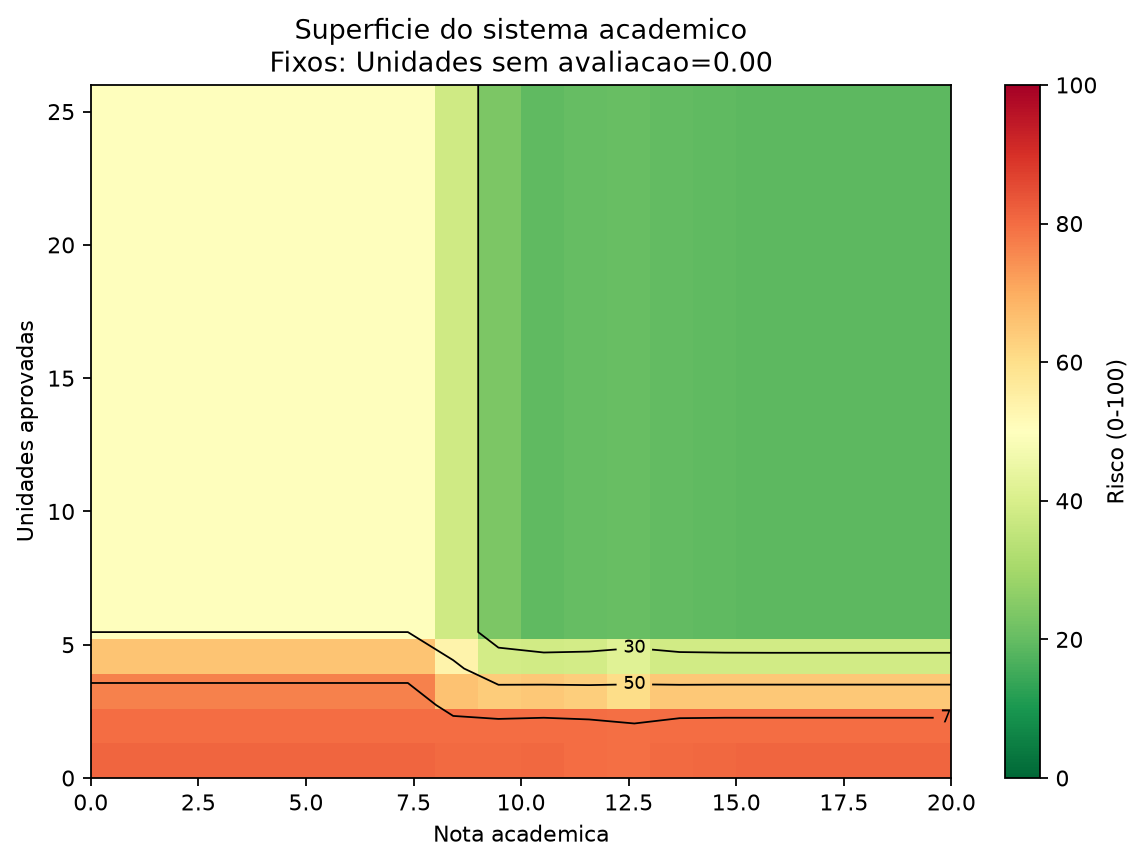

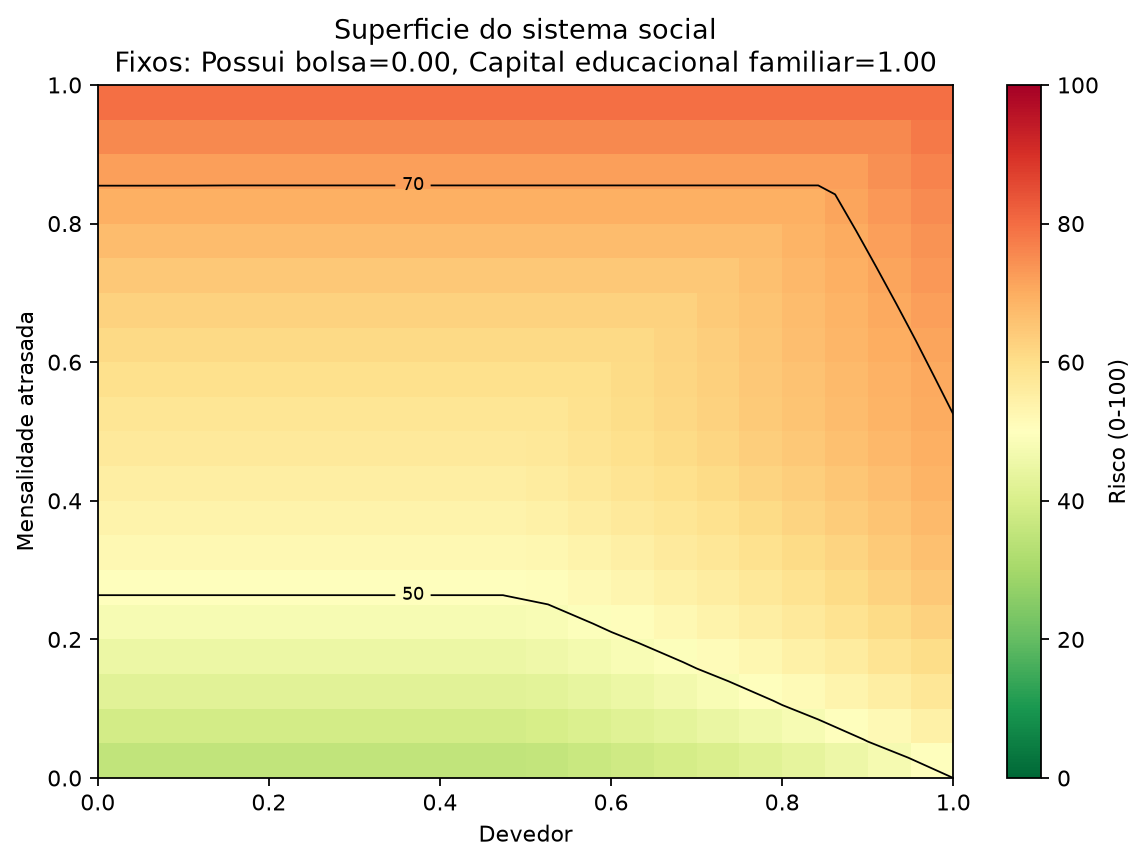

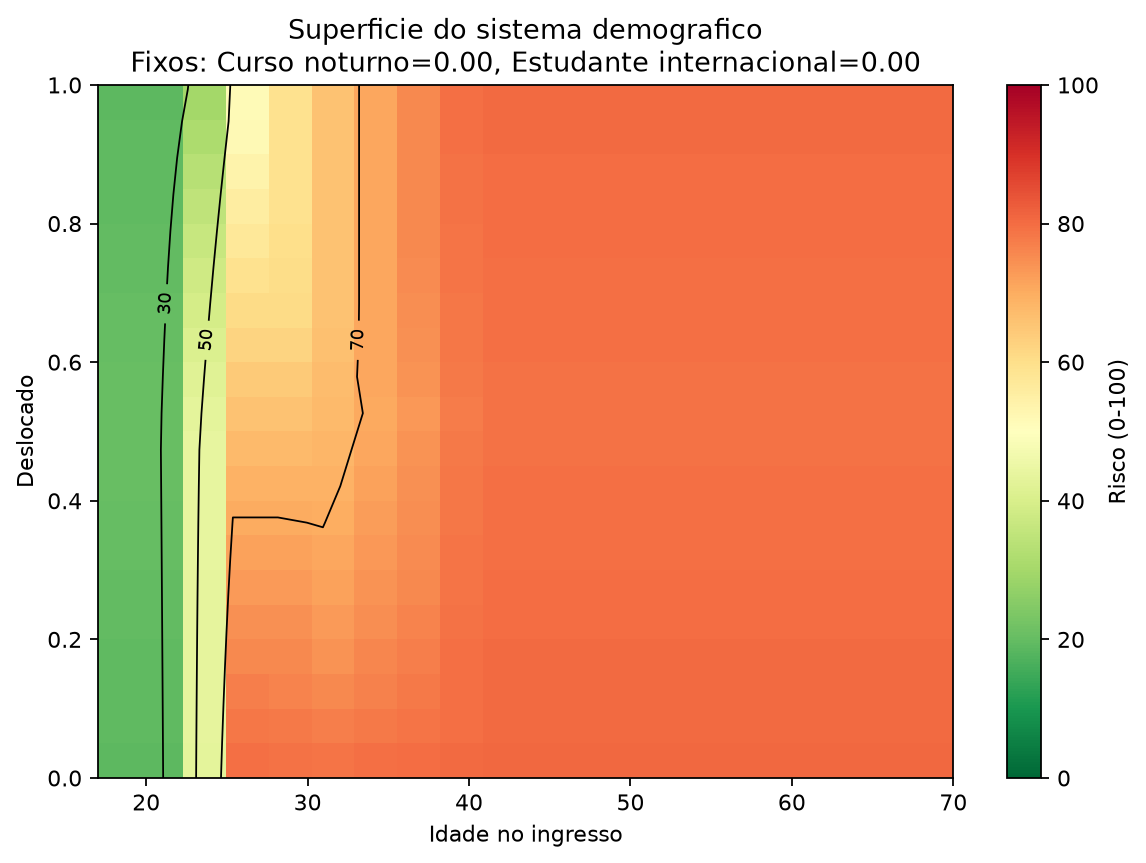

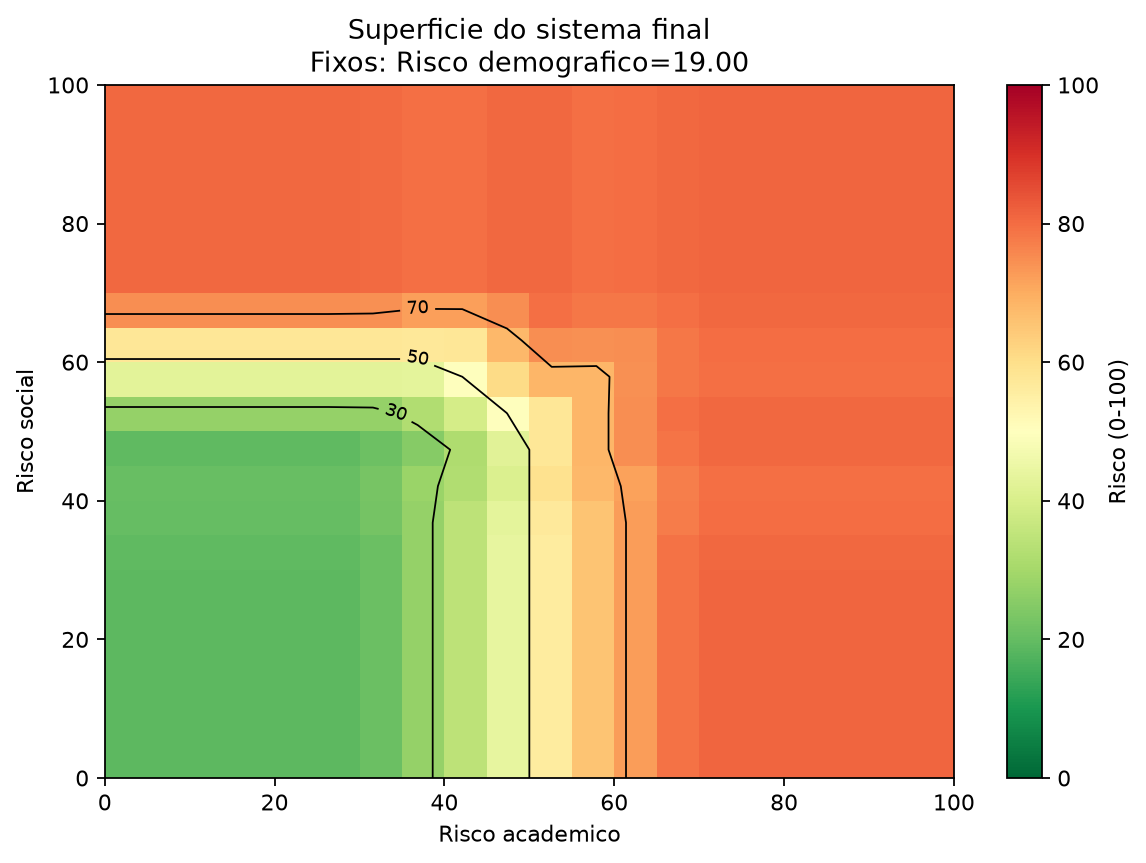

In [ ]:
show_images([
    OUTPUT_DIR / 'heatmap_academico.png',
    OUTPUT_DIR / 'heatmap_social.png',
    OUTPUT_DIR / 'heatmap_demografico.png',
    OUTPUT_DIR / 'heatmap_final.png',
])

## 5. Seleção do limiar na validação

F2 atribui peso maior ao recall. Isso representa a prioridade de reduzir estudantes em risco que não receberiam atenção. O teste não participa desta escolha.

Usamos nomes simples:

- **precisao**: entre os alunos sinalizados, quantos realmente evadiram;
- **recall**: entre os alunos que realmente evadiram, quantos foram sinalizados.

A fórmula usada é:

$$
F2 = 5 \times \frac{precisao \times recall}{4 \times precisao + recall}
$$

O fator 4 faz o recall pesar mais. Testamos todos os limiares inteiros de 0 a 100, escolhemos o maior F2 na validação e, em caso de empate, usamos o menor limiar para favorecer a identificação de alunos em risco.

Limiar selecionado: 22


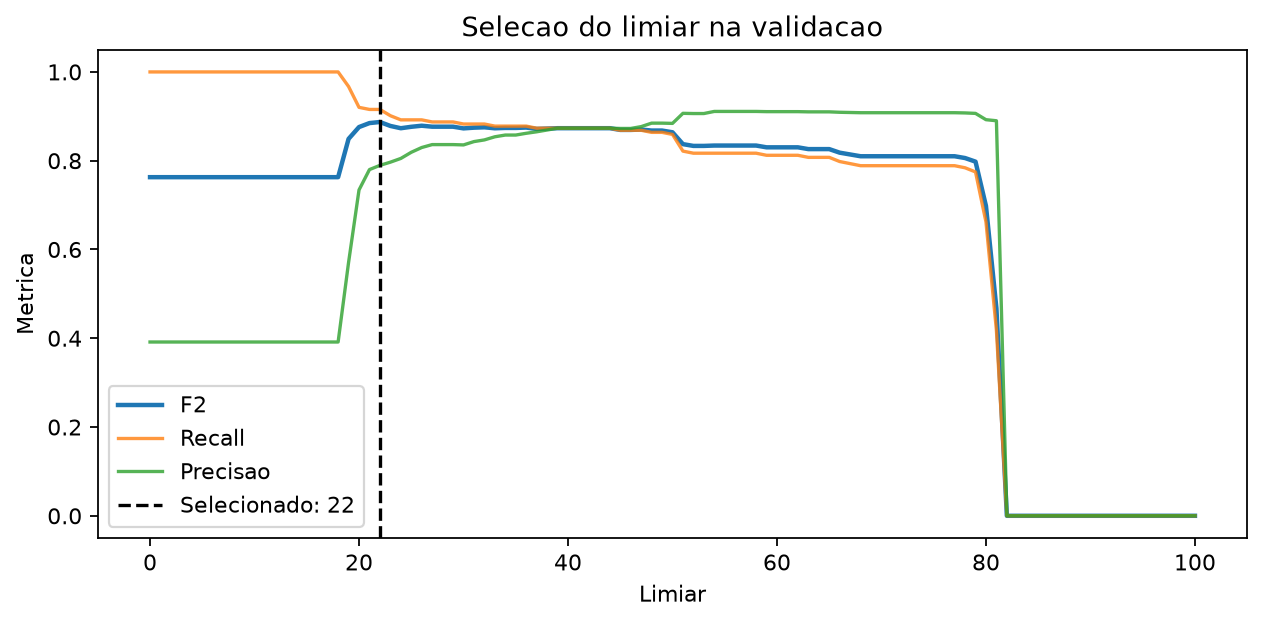

,threshold,precision_dropout,recall_dropout,f1_dropout,f2_dropout
20,20.0,0.734082,0.920188,0.816667,0.875782
21,21.0,0.780000,0.915493,0.842333,0.884755
22,22.0,0.789474,0.915493,0.847826,0.887170
23,23.0,0.796680,0.901408,0.845815,0.878317
25,25.0,0.818966,0.892019,0.853933,0.876384
26,26.0,0.829694,0.892019,0.859729,0.878816
27,27.0,0.836283,0.887324,0.861048,0.876623
28,28.0,0.836283,0.887324,0.861048,0.876623
29,29.0,0.836283,0.887324,0.861048,0.876623
32,32.0,0.846847,0.882629,0.864368,0.875233


In [ ]:
validation_metrics = pd.DataFrame([item.to_dict() for item in experiment.validation_sweep])
print(f'Limiar selecionado: {experiment.selected_validation_metrics.threshold:.0f}')
show_images([OUTPUT_DIR / 'validation_f2_threshold.png'])
validation_metrics.loc[validation_metrics['f2_dropout'].nlargest(10).index, [
    'threshold', 'precision_dropout', 'recall_dropout', 'f1_dropout', 'f2_dropout'
]].sort_values('threshold')

## 6. Avaliação final no teste

Os números abaixo são calculados uma única vez na partição de teste. Os intervalos bootstrap expressam a incerteza amostral, sem transformar o resultado em garantia de desempenho fora deste dataset.

,teste
threshold,22.0
accuracy,0.851376
precision_dropout,0.779661
recall_dropout,0.86385
f1_dropout,0.819599
f2_dropout,0.845588
specificity,0.843373
balanced_accuracy,0.853612
roc_auc,0.904378
pr_auc,0.83748


,lower,upper
accuracy,0.822018,0.878899
precision_dropout,0.739615,0.823256
recall_dropout,0.812207,0.906103
f1_dropout,0.782998,0.852018
f2_dropout,0.802973,0.881562
specificity,0.807154,0.879518
balanced_accuracy,0.821943,0.881427
roc_auc,0.873515,0.931194
pr_auc,0.784233,0.884874


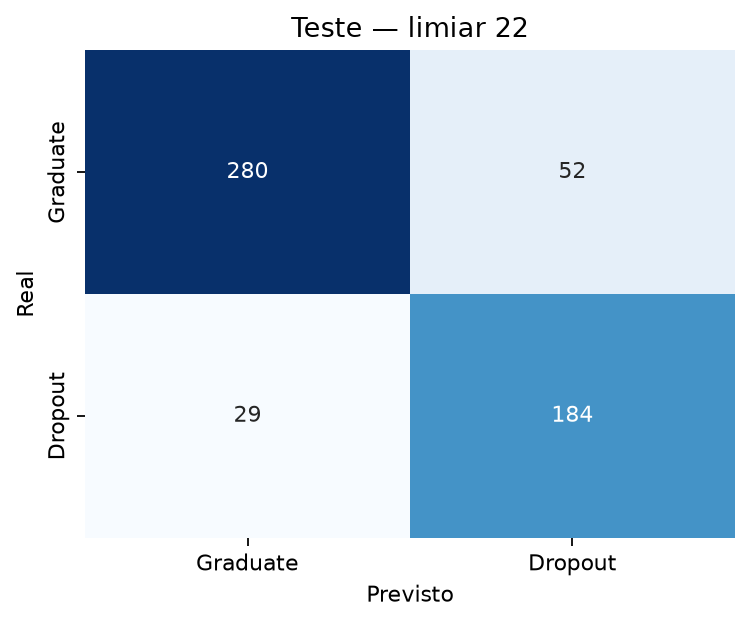

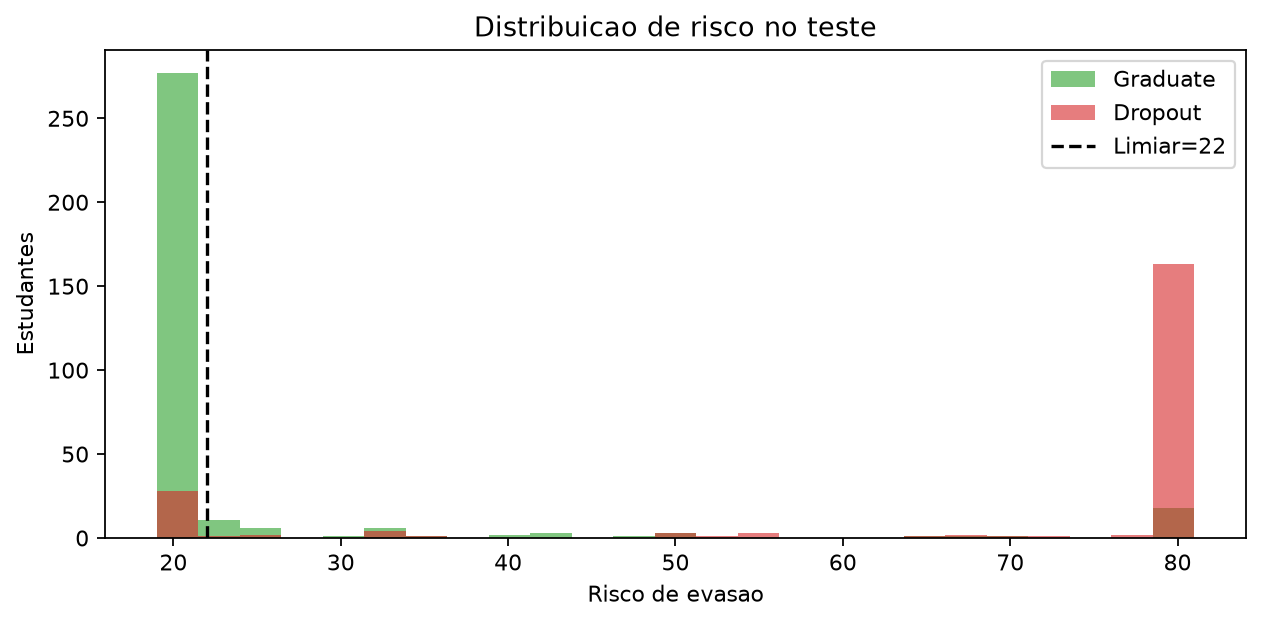

In [ ]:
test_metrics = pd.Series(experiment.test_metrics.to_dict()).drop('confusion_matrix')
display(test_metrics.to_frame('teste'))
display(pd.DataFrame(experiment.confidence_intervals).T)
show_images([
    OUTPUT_DIR / 'confusion_matrix_test.png',
    # OUTPUT_DIR / 'roc_pr_test.png',
    OUTPUT_DIR / 'risk_distribution_test.png',
])

## 7. Explicações individuais e análise de erros

São escolhidos o verdadeiro positivo, verdadeiro negativo, falso positivo e falso negativo de maior confiança, quando cada categoria existe. A explicação mostra os riscos intermediários e as regras que mais dispararam. Casos individuais ajudam a auditar o comportamento, mas não provam causalidade.


### Verdadeiro Positivo — row_id=99


,risco
risco_academico,81.000044
risco_social,81.000044
risco_demografico,18.999956
risco_evasao,81.000044


,sistema,regra,forca,suporte,risco_estimado
0,academico,SE nota_academica=baixa E aprovadas=medias E sem_avaliacao=poucas ENTAO risco=alto,1.0,29.321230,88.708322
1,social,SE debtor=sim E tuition_late=sim E scholarship=nao E capital_educacional=alto ENTAO risco=alto,1.0,27.000000,90.493408
2,demografico,SE idade=jovem E deslocado=sim E noturno=nao E internacional=nao ENTAO risco=baixo,1.0,1093.200000,28.406291
3,final,SE risco_academico=alto E risco_social=alto E risco_demografico=baixo ENTAO risco=alto,1.0,73.677086,93.591388


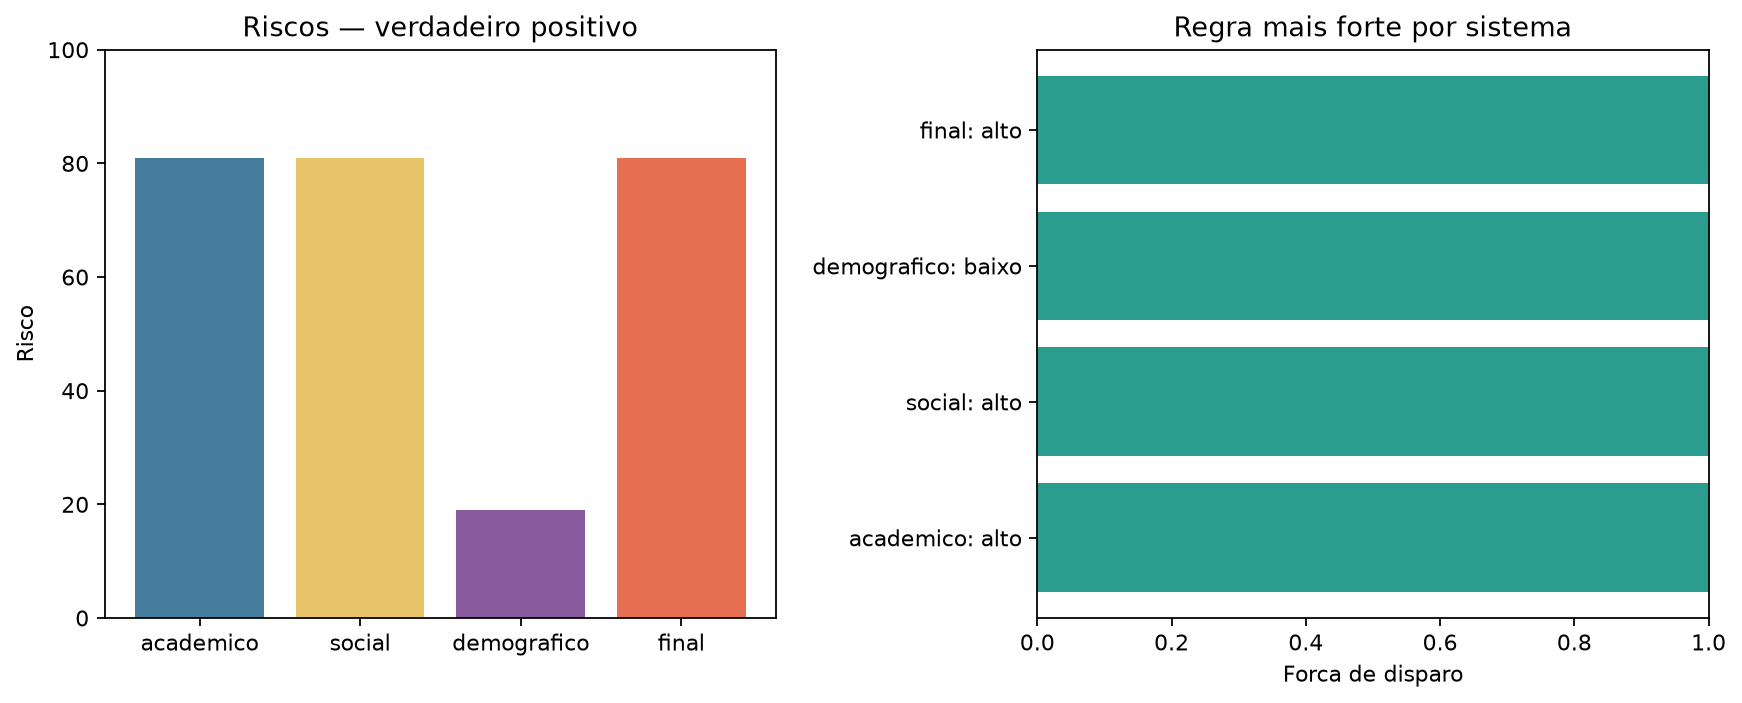


### Verdadeiro Negativo — row_id=1441


,risco
risco_academico,20.587521
risco_social,21.085237
risco_demografico,50.000000
risco_evasao,18.999956


,sistema,regra,forca,suporte,risco_estimado
0,academico,SE nota_academica=media E aprovadas=muitas E sem_avaliacao=poucas ENTAO risco=baixo,5.268889e-01,740.078811,23.143108
1,academico,SE nota_academica=alta E aprovadas=muitas E sem_avaliacao=poucas ENTAO risco=baixo,4.731111e-01,1033.006260,16.283438
2,social,SE debtor=nao E tuition_late=nao E scholarship=nao E capital_educacional=alto ENTAO risco=baixo,3.861034e-01,343.500000,33.416898
3,social,SE debtor=nao E tuition_late=nao E scholarship=nao E capital_educacional=medio ENTAO risco=baixo,2.637605e-01,686.500000,37.087186
4,demografico,SE idade=adulta E deslocado=sim E noturno=nao E internacional=nao ENTAO risco=medio,5.758775e-01,141.866667,58.482449
5,final,SE risco_academico=baixo E risco_social=baixo E risco_demografico=medio ENTAO risco=baixo,1.000000e+00,150.575095,17.066472
6,final,SE risco_academico=baixo E risco_social=baixo E risco_demografico=alto ENTAO risco=baixo,3.552714e-16,120.181562,21.781216


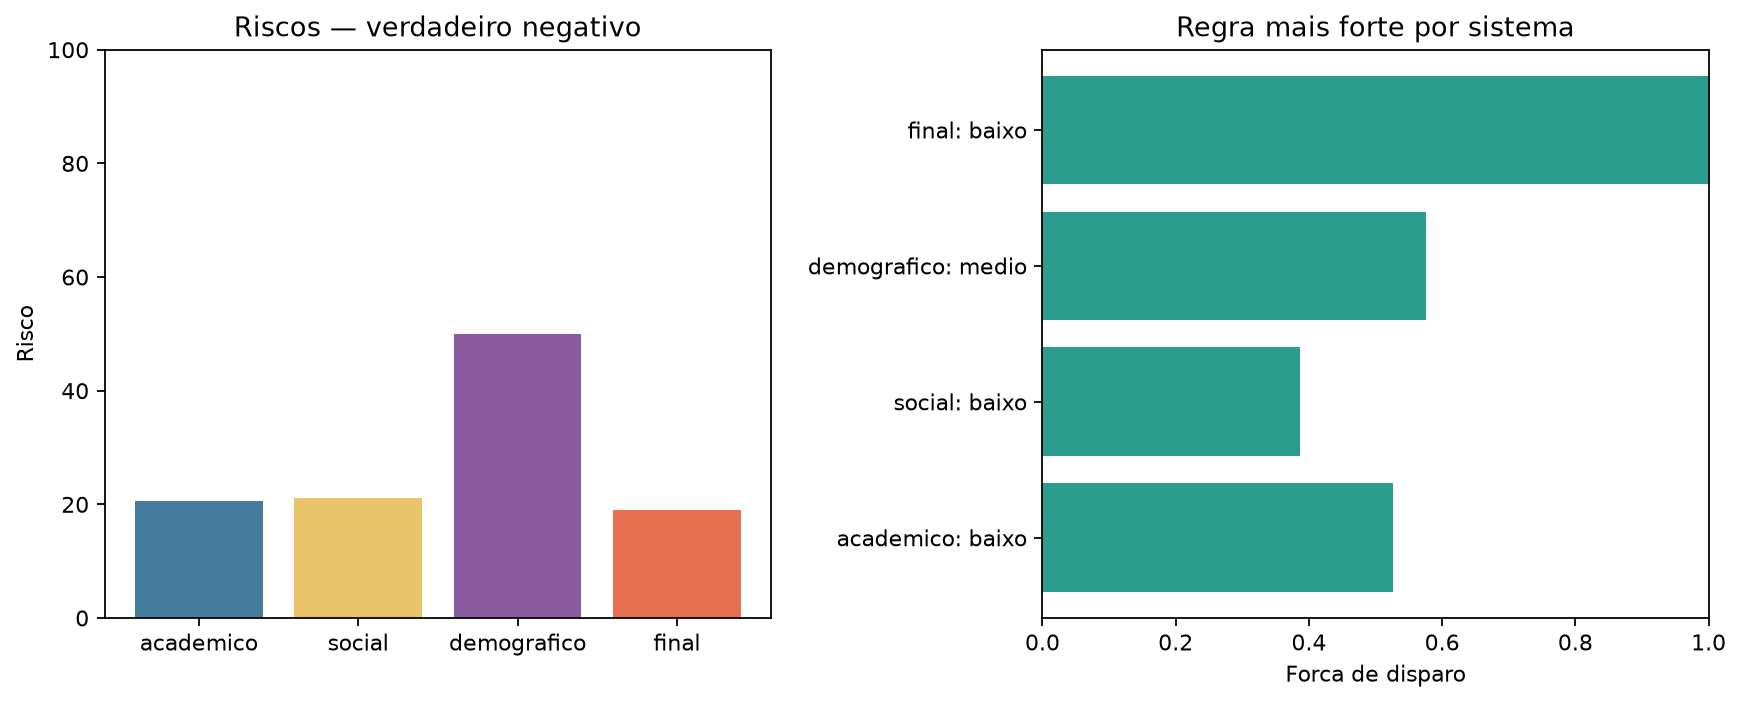


### Falso Positivo — row_id=66


,risco
risco_academico,81.000044
risco_social,20.681778
risco_demografico,18.999956
risco_evasao,81.000044


,sistema,regra,forca,suporte,risco_estimado
0,academico,SE nota_academica=baixa E aprovadas=poucas E sem_avaliacao=poucas ENTAO risco=alto,1.0,473.452222,89.540835
1,social,SE debtor=nao E tuition_late=nao E scholarship=sim E capital_educacional=baixo ENTAO risco=baixo,0.5,192.500000,10.105261
2,social,SE debtor=nao E tuition_late=nao E scholarship=sim E capital_educacional=medio ENTAO risco=baixo,0.5,376.000000,12.062438
3,demografico,SE idade=jovem E deslocado=sim E noturno=nao E internacional=nao ENTAO risco=baixo,1.0,1093.200000,28.406291
4,final,SE risco_academico=alto E risco_social=baixo E risco_demografico=baixo ENTAO risco=alto,1.0,208.868711,79.196644


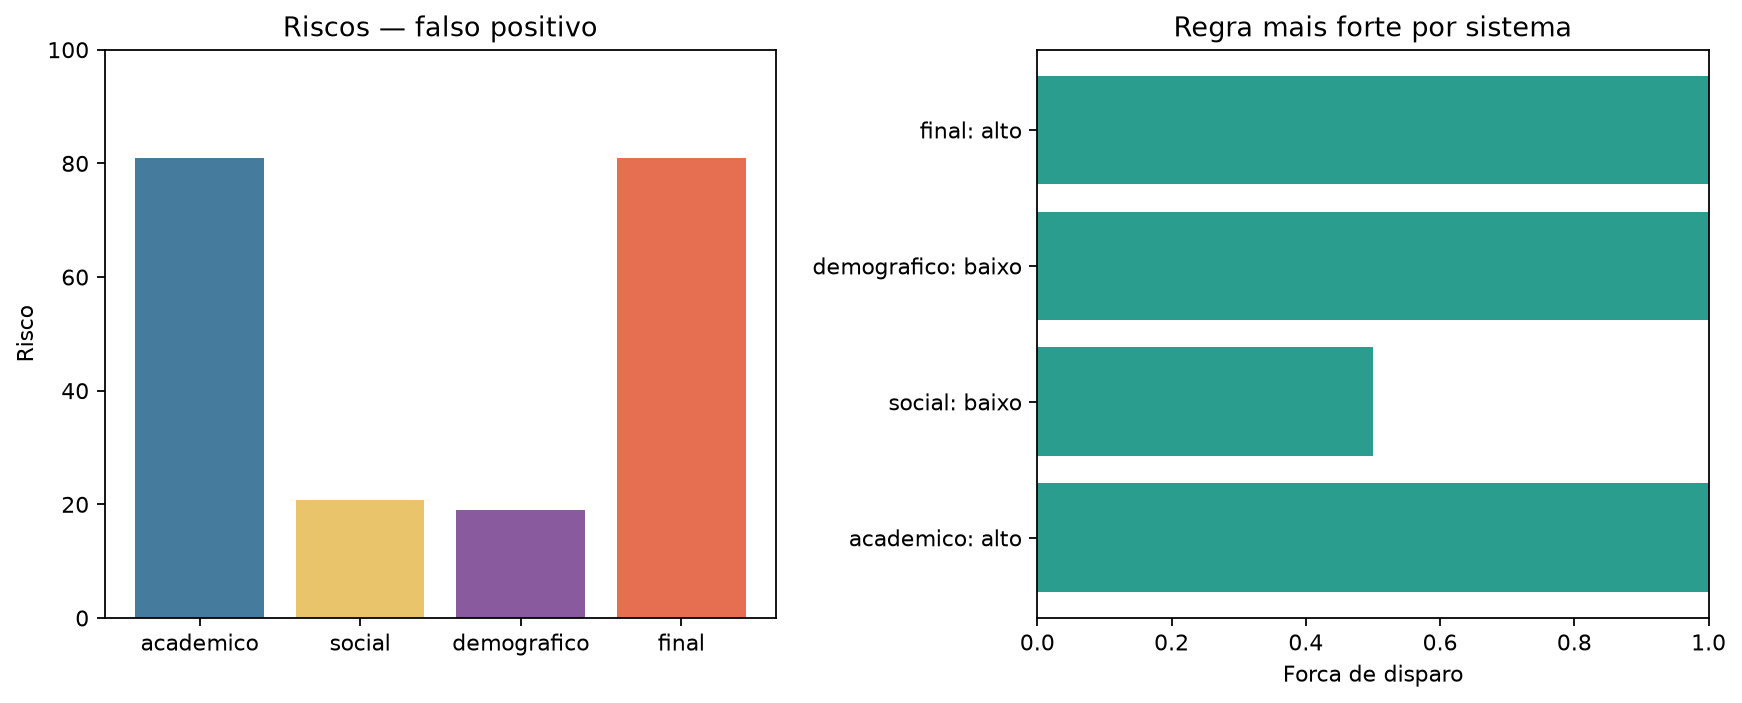


### Falso Negativo — row_id=552


,risco
risco_academico,20.552001
risco_social,50.000000
risco_demografico,27.896872
risco_evasao,18.999956


,sistema,regra,forca,suporte,risco_estimado
0,academico,SE nota_academica=media E aprovadas=muitas E sem_avaliacao=poucas ENTAO risco=baixo,0.537037,740.078811,23.143108
1,academico,SE nota_academica=alta E aprovadas=muitas E sem_avaliacao=poucas ENTAO risco=baixo,0.462963,1033.006260,16.283438
2,social,SE debtor=sim E tuition_late=nao E scholarship=nao E capital_educacional=alto ENTAO risco=medio,0.360009,25.500000,55.599641
3,social,SE debtor=sim E tuition_late=nao E scholarship=nao E capital_educacional=medio ENTAO risco=medio,0.337985,44.500000,56.480587
4,demografico,SE idade=jovem E deslocado=nao E noturno=nao E internacional=nao ENTAO risco=baixo,0.800000,512.000000,26.993789
5,demografico,SE idade=adulta E deslocado=nao E noturno=nao E internacional=nao ENTAO risco=alto,0.116482,232.266667,63.736116
6,final,SE risco_academico=baixo E risco_social=medio E risco_demografico=baixo ENTAO risco=baixo,1.000000,134.355077,18.338051


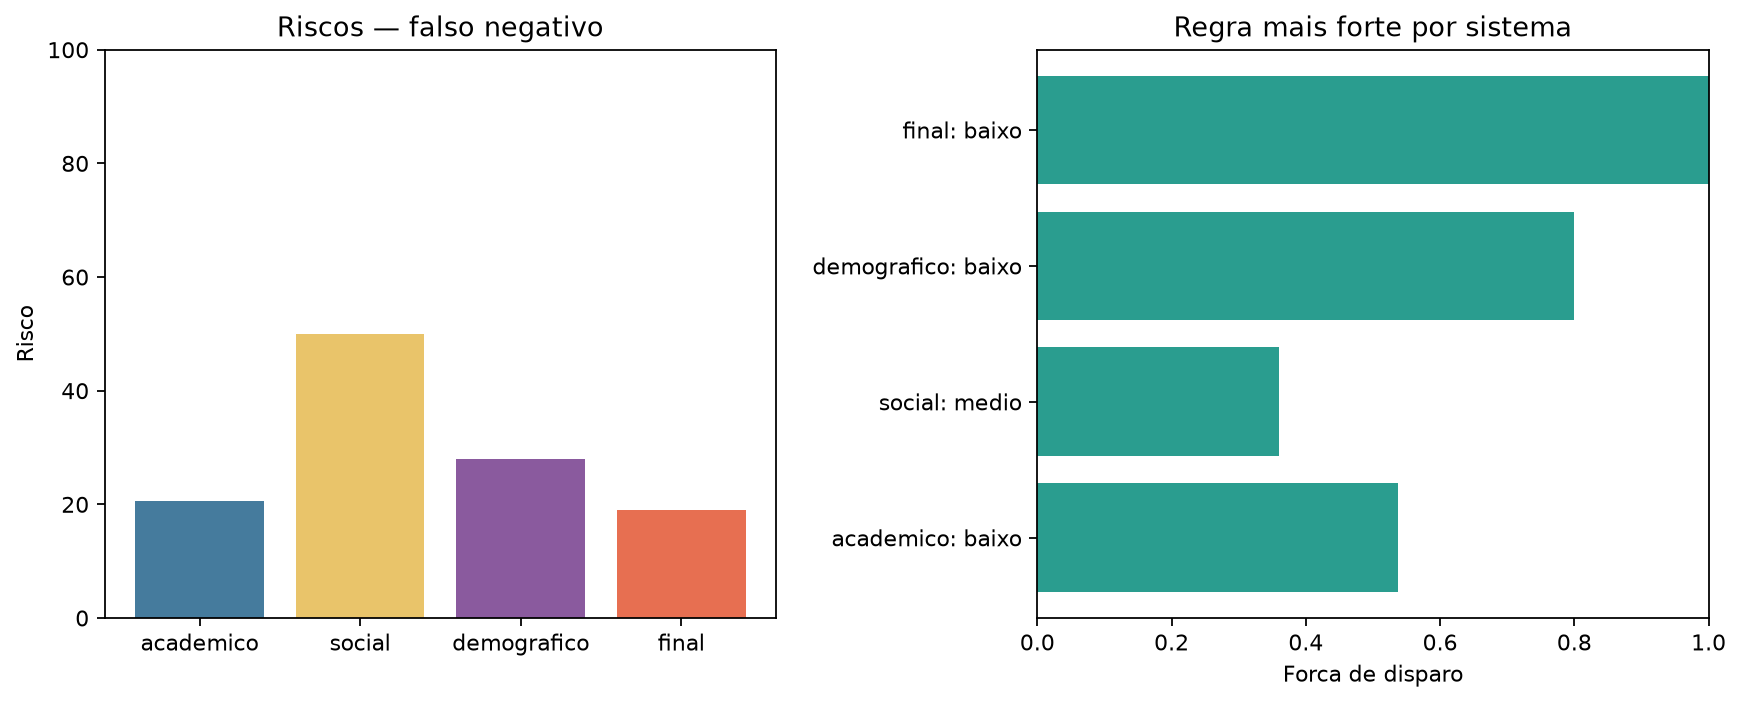

In [ ]:
for case_name, explanation in experiment.explanations.items():
    print(f'\n### {case_name.replace("_", " ").title()} — row_id={experiment.representative_row_ids[case_name]}')
    display(pd.Series(explanation.risks).to_frame('risco'))
    rule_rows: list[dict[str, object]] = []
    for block_name, block in explanation.blocks.items():
        for activation in block.activations:
            rule_rows.append({
                'sistema': block_name, 'regra': activation.label,
                'forca': activation.firing_strength, 'suporte': activation.support,
                'risco_estimado': activation.estimated_risk,
            })
    display(pd.DataFrame(rule_rows))
    show_images([OUTPUT_DIR / f'case_{case_name}.png'])

## 8. Análise descritiva por subgrupos

A tabela procura diferenças que mereçam investigação. Grupos com menos de 30 estudantes são marcados como insuficientes. Esta análise não certifica justiça, ausência de viés ou relação causal.

In [ ]:
experiment.subgroup_table.sort_values(['dimension', 'group'])

,dimension,group,n,sufficient,precision_dropout,recall_dropout,false_negative_rate,f2_dropout,accuracy
6,bolsa,0,414,True,0.804762,0.866667,0.133333,0.853535,0.838164
7,bolsa,1,131,True,0.576923,0.833333,0.166667,0.765306,0.893130
10,deslocado,0,229,True,0.868421,0.908257,0.091743,0.900000,0.890830
11,deslocado,1,316,True,0.696721,0.817308,0.182692,0.789963,0.822785
0,faixa_etaria,17-22,376,True,0.678832,0.845455,0.154545,0.805893,0.837766
1,faixa_etaria,23-30,78,True,0.914894,0.843137,0.156863,0.856574,0.846154
2,faixa_etaria,31-40,61,True,0.968750,0.911765,0.088235,0.922619,0.934426
3,faixa_etaria,41+,30,True,0.850000,0.944444,0.055556,0.923913,0.866667
8,internacional,0,532,True,0.775330,0.862745,0.137255,0.843720,0.851504
9,internacional,1,13,False,0.888889,0.888889,0.111111,0.888889,0.846154


## 9. Limitações e conclusão

- O estudo usa uma única instituição representada pelo dataset UCI; validação externa ainda é necessária.
- Os resultados são associações preditivas, não efeitos causais.
- A contribuição principal é combinar inferência Mamdani, regras aprendidas auditáveis, validação sem vazamento e explicações locais em um fluxo reproduzível.